# Running Palace Simulations

[Palace](https://awslabs.github.io/palace/) is an open-source 3D electromagnetic simulator supporting eigenmode, driven (S-parameter), and electrostatic simulations. This notebook demonstrates using the `gsim.palace` API to run a driven simulation on a CPW (coplanar waveguide) structure.

**Requirements:**

- IHP PDK: `uv pip install ihp-gdsfactory`
- [GDSFactory+](https://gdsfactory.com) account for cloud simulation

### Load a pcell from IHP PDK

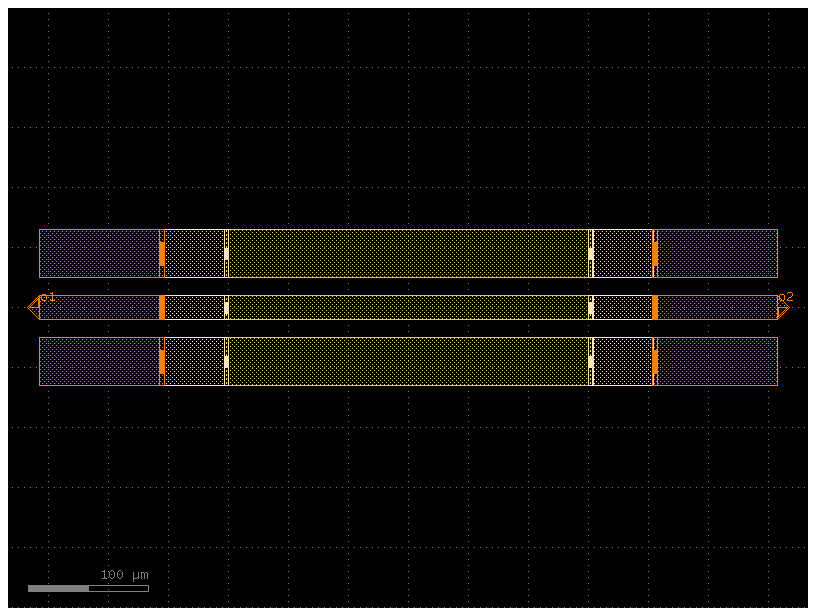

In [1]:
import gdsfactory as gf
from ihp import LAYER, PDK

PDK.activate()

# IHP SG13G2 via design rules
_VIA_RULES = {
    "TopVia2": {
        "size": 0.9,
        "spacing": 1.06,
        "enclosure": 0.5,
        "layer": LAYER.TopVia2drawing,
    },
    "TopVia1": {
        "size": 0.42,
        "spacing": 0.42,
        "enclosure": 0.42,
        "layer": LAYER.TopVia1drawing,
    },
}


@gf.cell
def _via_block(
    cols: int = 2,
    rows: int = 2,
    via_type: str = "TopVia2",
) -> gf.Component:
    """Create a block of vias following IHP design rules."""
    c = gf.Component()
    rules = _VIA_RULES[via_type]
    size = rules["size"]
    pitch = size + rules["spacing"]  # center-to-center

    via = gf.c.rectangle((size, size), layer=rules["layer"])
    for col in range(cols):
        for row in range(rows):
            ref = c << via
            ref.move((col * pitch, row * pitch))

    return c


def _via_pad_width(cols: int, via_type: str) -> float:
    """Width of via pad (via array + enclosure on both sides)."""
    rules = _VIA_RULES[via_type]
    pitch = rules["size"] + rules["spacing"]
    return (cols - 1) * pitch + rules["size"] + 2 * rules["enclosure"]


def _place_via_block(c, via_block, x, y_ctr, via_type, cols, rows):
    """Place a via block centered vertically at y_ctr."""
    rules = _VIA_RULES[via_type]
    pitch = rules["size"] + rules["spacing"]
    vb = c << via_block
    vb.move((x + rules["enclosure"], y_ctr - ((rows - 1) * pitch + rules["size"]) / 2))


@gf.cell
def gsg_electrode_tm2_tm1_m5(
    tm2_length: float = 100,
    tm1_length: float = 50,
    m5_length: float = 300,
    s_width: float = 20,
    g_width: float = 40,
    gap_width: float = 15,
    tv2_cols: int = 2,
    tv2_rows: int = 10,
    tv1_cols: int = 4,
    tv1_rows: int = 10,
) -> gf.Component:
    """GSG electrode: TM2 -> TopVia2 -> TM1 -> TopVia1 -> M5 -> TopVia1 -> TM1 -> TopVia2 -> TM2.

    Args:
        tm2_length: Length of TM2 sections at each end (um)
        tm1_length: Length of TM1 sections between vias (um)
        m5_length: Length of Metal5 section in the middle (um)
        s_width: Signal trace width (um)
        g_width: Ground trace width (um)
        gap_width: Gap between signal and ground (um)
        tv2_cols/rows: TopVia2 array size
        tv1_cols/rows: TopVia1 array size
    """
    c = gf.Component()

    tv2_w = _via_pad_width(tv2_cols, "TopVia2")
    tv1_w = _via_pad_width(tv1_cols, "TopVia1")

    # Total length: TM2 | TV2 | TM1 | TV1 | M5 | TV1 | TM1 | TV2 | TM2
    total = 2 * tm2_length + 2 * tv2_w + 2 * tm1_length + 2 * tv1_w + m5_length

    # Section x-coordinates (left edges, centered at x=0)
    x = -total / 2
    sections = [
        ("tm2_l", tm2_length),
        ("tv2_l", tv2_w),
        ("tm1_l", tm1_length),
        ("tv1_l", tv1_w),
        ("m5", m5_length),
        ("tv1_r", tv1_w),
        ("tm1_r", tm1_length),
        ("tv2_r", tv2_w),
        ("tm2_r", tm2_length),
    ]
    xs = {}
    for name, width in sections:
        xs[name] = x
        x += width

    # Via blocks
    tv2_block = _via_block(cols=tv2_cols, rows=tv2_rows, via_type="TopVia2")
    tv1_block = _via_block(cols=tv1_cols, rows=tv1_rows, via_type="TopVia1")

    # GSG traces
    traces = [
        (0, s_width),
        (s_width / 2 + gap_width + g_width / 2, g_width),
        (-(s_width / 2 + gap_width + g_width / 2), g_width),
    ]

    TM2 = LAYER.TopMetal2drawing
    TM1 = LAYER.TopMetal1drawing
    M5 = LAYER.Metal5drawing

    for y_ctr, w in traces:
        yb = y_ctr - w / 2

        # TM2 left
        (c << gf.c.rectangle((tm2_length, w), layer=TM2)).move((xs["tm2_l"], yb))

        # TopVia2 left transition (TM2 + TM1 overlap + vias)
        (c << gf.c.rectangle((tv2_w, w), layer=TM2)).move((xs["tv2_l"], yb))
        (c << gf.c.rectangle((tv2_w, w), layer=TM1)).move((xs["tv2_l"], yb))
        _place_via_block(
            c, tv2_block, xs["tv2_l"], y_ctr, "TopVia2", tv2_cols, tv2_rows
        )

        # TM1 left
        (c << gf.c.rectangle((tm1_length, w), layer=TM1)).move((xs["tm1_l"], yb))

        # TopVia1 left transition (TM1 + M5 overlap + vias)
        (c << gf.c.rectangle((tv1_w, w), layer=TM1)).move((xs["tv1_l"], yb))
        (c << gf.c.rectangle((tv1_w, w), layer=M5)).move((xs["tv1_l"], yb))
        _place_via_block(
            c, tv1_block, xs["tv1_l"], y_ctr, "TopVia1", tv1_cols, tv1_rows
        )

        # Metal5 middle
        (c << gf.c.rectangle((m5_length, w), layer=M5)).move((xs["m5"], yb))

        # TopVia1 right transition
        (c << gf.c.rectangle((tv1_w, w), layer=TM1)).move((xs["tv1_r"], yb))
        (c << gf.c.rectangle((tv1_w, w), layer=M5)).move((xs["tv1_r"], yb))
        _place_via_block(
            c, tv1_block, xs["tv1_r"], y_ctr, "TopVia1", tv1_cols, tv1_rows
        )

        # TM1 right
        (c << gf.c.rectangle((tm1_length, w), layer=TM1)).move((xs["tm1_r"], yb))

        # TopVia2 right transition
        (c << gf.c.rectangle((tv2_w, w), layer=TM2)).move((xs["tv2_r"], yb))
        (c << gf.c.rectangle((tv2_w, w), layer=TM1)).move((xs["tv2_r"], yb))
        _place_via_block(
            c, tv2_block, xs["tv2_r"], y_ctr, "TopVia2", tv2_cols, tv2_rows
        )

        # TM2 right
        (c << gf.c.rectangle((tm2_length, w), layer=TM2)).move((xs["tm2_r"], yb))

    # Ports at TM2 ends
    c.add_port(
        name="o1",
        center=(-total / 2, 0),
        width=s_width,
        orientation=180,
        port_type="electrical",
        layer=TM2,
    )
    c.add_port(
        name="o2",
        center=(total / 2, 0),
        width=s_width,
        orientation=0,
        port_type="electrical",
        layer=TM2,
    )

    return c


c = gsg_electrode_tm2_tm1_m5()
cc = c.copy()
cc.draw_ports()
cc

### Configure and run simulation with DrivenSim

In [2]:
from gsim.palace import DrivenSim

# Create simulation object
sim = DrivenSim()

# Set output directory
sim.set_output_dir("./palace-sim-cpw")

# Set the component geometry
sim.set_geometry(c)

# Configure layer stack from active PDK
sim.set_stack(substrate_thickness=2.0, air_above=300.0)

# Configure left CPW port (single port at signal center)
sim.add_cpw_port("o1", layer="topmetal2", s_width=20, gap_width=15)

# Configure right CPW port (single port at signal center)
sim.add_cpw_port("o2", layer="topmetal2", s_width=20, gap_width=15)

# Configure driven simulation (frequency sweep for S-parameters)
sim.set_driven(fmin=1e9, fmax=100e9, num_points=300)

# Validate configuration
print(sim.validate_config())

Validation: PASSED


In [3]:
# Generate mesh with planar conductors (presets: "coarse", "default", "fine")
sim.mesh(preset="default", planar_conductors=False)

Mesh Summary
Dimensions: 715.3 x 230.0 x 318.3 µm
Nodes:      7,823
Elements:   60,674
Tetrahedra: 43,266
Edge length: 0.40 - 246.54 µm
Quality:    0.461 (min: 0.001)
SICN:       0.502 (all valid)
----------------------------------------
Volumes (5):
  - topvia1 [1]
  - topvia2 [2]
  - SiO2 [3]
  - passive [4]
  - air [5]
Surfaces (17):
  - metal5_xy [6]
  - metal5_z [7]
  - topmetal1_xy [8]
  - topmetal1_z [9]
  - topmetal2_xy [10]
  - topmetal2_z [11]
  - P1_E0 [12]
  - P1_E1 [13]
  - P2_E0 [14]
  - P2_E1 [15]
  - SiO2__topvia1 [16]
  - SiO2__topvia2 [17]
  - SiO2__None [18]
  - SiO2__passive [19]
  - passive__None [20]
  - air__passive [21]
  - air__None [22]
----------------------------------------
Mesh:   palace-sim-cpw/palace.msh

In [4]:
sim.plot_mesh(show_groups=["metal", "P", "via"])

Widget(value='<iframe src="http://localhost:43331/index.html?ui=P_0x7235ddaf3470_0&reconnect=auto" class="pyvi…

### Run simulation on cloud

In [5]:
# Run simulation on GDSFactory+ cloud
results = sim.run()

  palace-9151f7c1  completed  2m 30s
Extracting results.tar.gz...
Downloaded 10 files to /home/delfina/projects/gsim/nbs/sim-data-palace-9151f7c1


In [6]:
results.plot_interactive()

Port mapping: Port 1: o1, Port 2: o2


In [7]:
results.plot_interactive(phase=True)

Port mapping: Port 1: o1, Port 2: o2
